In [24]:


import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [25]:
import sys
from pathlib import Path
import importlib.util

# Add src directory to Python path
src_path = Path.cwd().parent / 'src'
sys.path.insert(0, str(src_path))

# Import custom_transformers module properly
import custom_transformers

# Verify the classes are in the module
print("Classes in custom_transformers module:")
print(f"  - DropColumns: {hasattr(custom_transformers, 'DropColumns')}")
print(f"  - DateFeatures: {hasattr(custom_transformers, 'DateFeatures')}")
print(f"  - CyclicalFeatures: {hasattr(custom_transformers, 'CyclicalFeatures')}")

# Make sure the module is registered in sys.modules
sys.modules['custom_transformers'] = custom_transformers

# Also register the classes in __main__ just in case
import __main__
__main__.DropColumns = custom_transformers.DropColumns
__main__.DateFeatures = custom_transformers.DateFeatures
__main__.CyclicalFeatures = custom_transformers.CyclicalFeatures

# Now load the model
import joblib

model_path = Path('../models/mobile_data_consumption_pipeline.pkl')
if model_path.exists():
    print(f"\nLoading model from: {model_path}")
    model_pipeline = joblib.load(model_path)
    print("✓ Model loaded successfully!")
    print(f"Model type: {type(model_pipeline)}")
    
    # Show pipeline structure
    if hasattr(model_pipeline, 'named_steps'):
        print("\nPipeline steps:")
        for step_name, step in model_pipeline.named_steps.items():
            print(f"  • {step_name}: {type(step).__name__}")
else:
    print(f"\nModel not found at: {model_path}")
    print(f"Current working directory: {Path.cwd()}")
    print(f"Looking for: {model_path.resolve()}")

Classes in custom_transformers module:
  - DropColumns: True
  - DateFeatures: True
  - CyclicalFeatures: True

Loading model from: ..\models\mobile_data_consumption_pipeline.pkl
✓ Model loaded successfully!
Model type: <class 'sklearn.pipeline.Pipeline'>

Pipeline steps:
  • preprocessing: Pipeline
  • model: GradientBoostingRegressor


In [26]:
# ============================================================
# LOAD TEST DATA
# ============================================================

TEST_DATA_PATH = "../data/processed/test_data.parquet"

test_data = pd.read_parquet(TEST_DATA_PATH)

print(f"Test data shape: {test_data.shape}")

display(test_data.head())

Test data shape: (2002, 18)


,user_id,measurement_date,hours_streaming,hours_social,hours_messaging,hours_gaming,is_peak_hour_user,is_weekend,age_group,plan_type,device_type,network_type,data_usage_category,streaming_data_gb,social_data_gb,messaging_data_gb,gaming_data_gb,total_data_gb
0,SUB8984705,2026-03-31,1.73,4.73,1.23,0.85,1,1,25-34,Postpaid_Premium,Premium_Smartphone,4G,Moderate,2.17,1.38,0.01,0.11,4.13
1,SUB6140709,2026-03-20,0.40,0.26,0.17,1.82,0,0,55+,Prepaid_Monthly,Mid_Range,4G+,Light,0.55,0.07,0.00,0.29,1.01
2,SUB3654810,2026-04-16,0.91,0.28,0.01,0.03,0,0,55+,Prepaid_Daily,Mid_Range,4G,Light,1.00,0.05,0.00,0.00,1.04
3,SUB6876924,2026-04-01,1.66,1.18,0.09,0.25,0,0,18-24,Postpaid_Premium,Basic_Phone,4G+,Moderate,3.95,0.29,0.00,0.03,3.88
4,SUB3498002,2026-03-27,0.45,1.87,0.05,0.63,0,0,55+,Postpaid_Unlimited,Premium_Smartphone,4G,Light,0.79,0.36,0.00,0.12,1.33


In [27]:
# ============================================================
# GENERATE PREDICTIONS
# ============================================================

TARGET = "total_data_gb"

X_test = test_data.drop(columns=[TARGET])
y_test = test_data[TARGET]

test_data["predicted_data_gb"] = model_pipeline.predict(X_test)

print("Predictions generated successfully.")

display(
    test_data[
        [
            TARGET,
            "predicted_data_gb"
        ]
    ].head(10)
)

Predictions generated successfully.


,total_data_gb,predicted_data_gb
0,4.13,3.92
1,1.01,0.83
2,1.04,1.14
3,3.88,4.65
4,1.33,1.12
5,3.89,4.51
6,1.60,1.44
7,0.25,0.27
8,2.14,2.83
9,0.54,0.71


In [28]:
# ============================================================
# FINAL MODEL PERFORMANCE
# ============================================================

if "predicted_data_gb" not in test_data.columns:
    test_data["predicted_data_gb"] = model_pipeline.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_data["predicted_data_gb"]
    )
)

mae = mean_absolute_error(
    y_test,
    test_data["predicted_data_gb"]
)

r2 = r2_score(
    y_test,
    test_data["predicted_data_gb"]
)

print("=" * 70)
print("FINAL MODEL PERFORMANCE ON UNSEEN TEST DATA")
print("=" * 70)

print(f"MAE : {mae:.4f} GB")
print(f"RMSE: {rmse:.4f} GB")
print(f"R²  : {r2:.4f}")

FINAL MODEL PERFORMANCE ON UNSEEN TEST DATA
MAE : 0.4573 GB
RMSE: 0.9223 GB
R²  : 0.9562


In [29]:
# ============================================================
# BUSINESS KPI: MAE THRESHOLD
# ============================================================

MAE_TARGET = 1.5

print("\nML BUSINESS KPI")
print("-" * 30)

if mae <= MAE_TARGET:
    print(
        f"PASS: MAE = {mae:.2f} GB "
        f"(Target ≤ {MAE_TARGET} GB)"
    )
else:
    print(
        f"FAIL: MAE = {mae:.2f} GB "
        f"(Target ≤ {MAE_TARGET} GB)"
    )


ML BUSINESS KPI
------------------------------
PASS: MAE = 0.46 GB (Target ≤ 1.5 GB)


In [30]:
# ============================================================
# PREDICTION ERROR
# ============================================================

test_data["prediction_error_gb"] = (
    test_data["total_data_gb"]
    - test_data["predicted_data_gb"]
)

test_data["absolute_error_gb"] = (
    test_data["prediction_error_gb"].abs()
)

display(
    test_data[
        [
            "total_data_gb",
            "predicted_data_gb",
            "prediction_error_gb",
            "absolute_error_gb"
        ]
    ].head(10)
)

,total_data_gb,predicted_data_gb,prediction_error_gb,absolute_error_gb
0,4.13,3.92,0.22,0.22
1,1.01,0.83,0.18,0.18
2,1.04,1.14,-0.09,0.09
3,3.88,4.65,-0.77,0.77
4,1.33,1.12,0.21,0.21
5,3.89,4.51,-0.61,0.61
6,1.60,1.44,0.15,0.15
7,0.25,0.27,-0.01,0.01
8,2.14,2.83,-0.69,0.69
9,0.54,0.71,-0.17,0.17


In [31]:
PRICING_BENCHMARKS = {
    'Postpaid': {
        'base_rate_per_gb': 49.00,  # R49/GB for postpaid
        'monthly_fee': 99.00,       # Base monthly fee
        'premium_multiplier': 1.3,
        'entry_multiplier': 0.7
    },
    'Prepaid': {
        'base_rate_per_gb': 69.00,  # R69/GB for prepaid (higher per GB)
        'monthly_fee': 29.00,       # Minimum top-up
        'premium_multiplier': 1.2,
        'entry_multiplier': 0.65
    },
    'Prepaid_Daily': {
        'base_rate_per_gb': 99.00,  # R99/GB for daily bundles
        'monthly_fee': 15.00,       # Daily rate
        'premium_multiplier': 1.1,
        'entry_multiplier': 0.6
    },
    'Postpaid_Basic': {
        'base_rate_per_gb': 59.00,  # R59/GB for basic postpaid
        'monthly_fee': 79.00,       # Basic monthly fee
        'premium_multiplier': 1.25,
        'entry_multiplier': 0.65
    }
}

def calculate_arpu_zar(row):
    """Calculate ARPU in South African Rands based on usage and plan type"""
    plan = row['plan_type']
    usage_gb = row['total_data_gb']
    
    # Get pricing for this plan type
    pricing = PRICING_BENCHMARKS.get(plan, PRICING_BENCHMARKS['Prepaid'])
    
    # Base ARPU calculation (data usage + monthly fee)
    data_charge = usage_gb * pricing['base_rate_per_gb']
    monthly_fee = pricing['monthly_fee']
    
    # Apply volume discounts based on usage tiers
    if usage_gb > 30:
        # Heavy users get volume discount (MTN/Vodacom do this)
        arpu = (data_charge * 0.75) + monthly_fee
    elif usage_gb > 20:
        arpu = (data_charge * 0.82) + monthly_fee
    elif usage_gb > 10:
        arpu = (data_charge * 0.90) + monthly_fee
    elif usage_gb > 5:
        arpu = data_charge + monthly_fee
    else:
        # Light users pay premium per GB (typical for prepaid)
        arpu = (data_charge * 1.15) + monthly_fee
    
    # Ensure minimum ARPU (realistic SA market floors)
    min_arpu = 29 if 'Prepaid' in plan else 79
    return round(max(min_arpu, arpu), 2)

# Calculate ARPU for each user
test_data['arpu_zar'] = test_data.apply(calculate_arpu_zar, axis=1)


In [32]:
test_data.head()

,user_id,measurement_date,hours_streaming,hours_social,hours_messaging,hours_gaming,is_peak_hour_user,is_weekend,age_group,plan_type,device_type,network_type,data_usage_category,streaming_data_gb,social_data_gb,messaging_data_gb,gaming_data_gb,total_data_gb,predicted_data_gb,prediction_error_gb,absolute_error_gb,arpu_zar
0,SUB8984705,2026-03-31,1.73,4.73,1.23,0.85,1,1,25-34,Postpaid_Premium,Premium_Smartphone,4G,Moderate,2.17,1.38,0.01,0.11,4.13,3.92,0.22,0.22,357.09
1,SUB6140709,2026-03-20,0.40,0.26,0.17,1.82,0,0,55+,Prepaid_Monthly,Mid_Range,4G+,Light,0.55,0.07,0.00,0.29,1.01,0.83,0.18,0.18,109.11
2,SUB3654810,2026-04-16,0.91,0.28,0.01,0.03,0,0,55+,Prepaid_Daily,Mid_Range,4G,Light,1.00,0.05,0.00,0.00,1.04,1.14,-0.09,0.09,133.86
3,SUB6876924,2026-04-01,1.66,1.18,0.09,0.25,0,0,18-24,Postpaid_Premium,Basic_Phone,4G+,Moderate,3.95,0.29,0.00,0.03,3.88,4.65,-0.77,0.77,336.88
4,SUB3498002,2026-03-27,0.45,1.87,0.05,0.63,0,0,55+,Postpaid_Unlimited,Premium_Smartphone,4G,Light,0.79,0.36,0.00,0.12,1.33,1.12,0.21,0.21,134.93


In [33]:
test_data.columns

Index(['user_id', 'measurement_date', 'hours_streaming', 'hours_social',
       'hours_messaging', 'hours_gaming', 'is_peak_hour_user', 'is_weekend',
       'age_group', 'plan_type', 'device_type', 'network_type',
       'data_usage_category', 'streaming_data_gb', 'social_data_gb',
       'messaging_data_gb', 'gaming_data_gb', 'total_data_gb',
       'predicted_data_gb', 'prediction_error_gb', 'absolute_error_gb',
       'arpu_zar'],
      dtype='object')

In [34]:
df = test_data.copy()

TELECOM CONSUMPTION ANALYSIS
Total Records: 2,002
Unique Users: 2,001
Date Range: 2026-03-19 00:00:00 to 2026-04-17 00:00:00

TELECOM METRICS CALCULATION

Telecom Metrics Summary:
Average Data per Hour: 0.65 GB/hour
Average ARPU per GB: R123.32
Network Efficiency: 0.65 GB/hour
Peak Hour Users: 595 (29.7%)

MODEL PERFORMANCE (TELECOM CONTEXT)
MAE: 0.457 GB  |  RMSE: 0.922 GB  |  R²: 0.956  |  MAPE: 16.3%

Model Error by Network Condition:
                                absolute_error_gb  prediction_error_gb  \
is_peak_hour_user network_type                                           
0                 3G                         0.15                -0.03   
                  4G                         0.32                -0.07   
                  4G+                        0.53                -0.07   
                  5G                         0.68                 0.00   
1                 3G                         0.20                -0.07   
                  4G                    

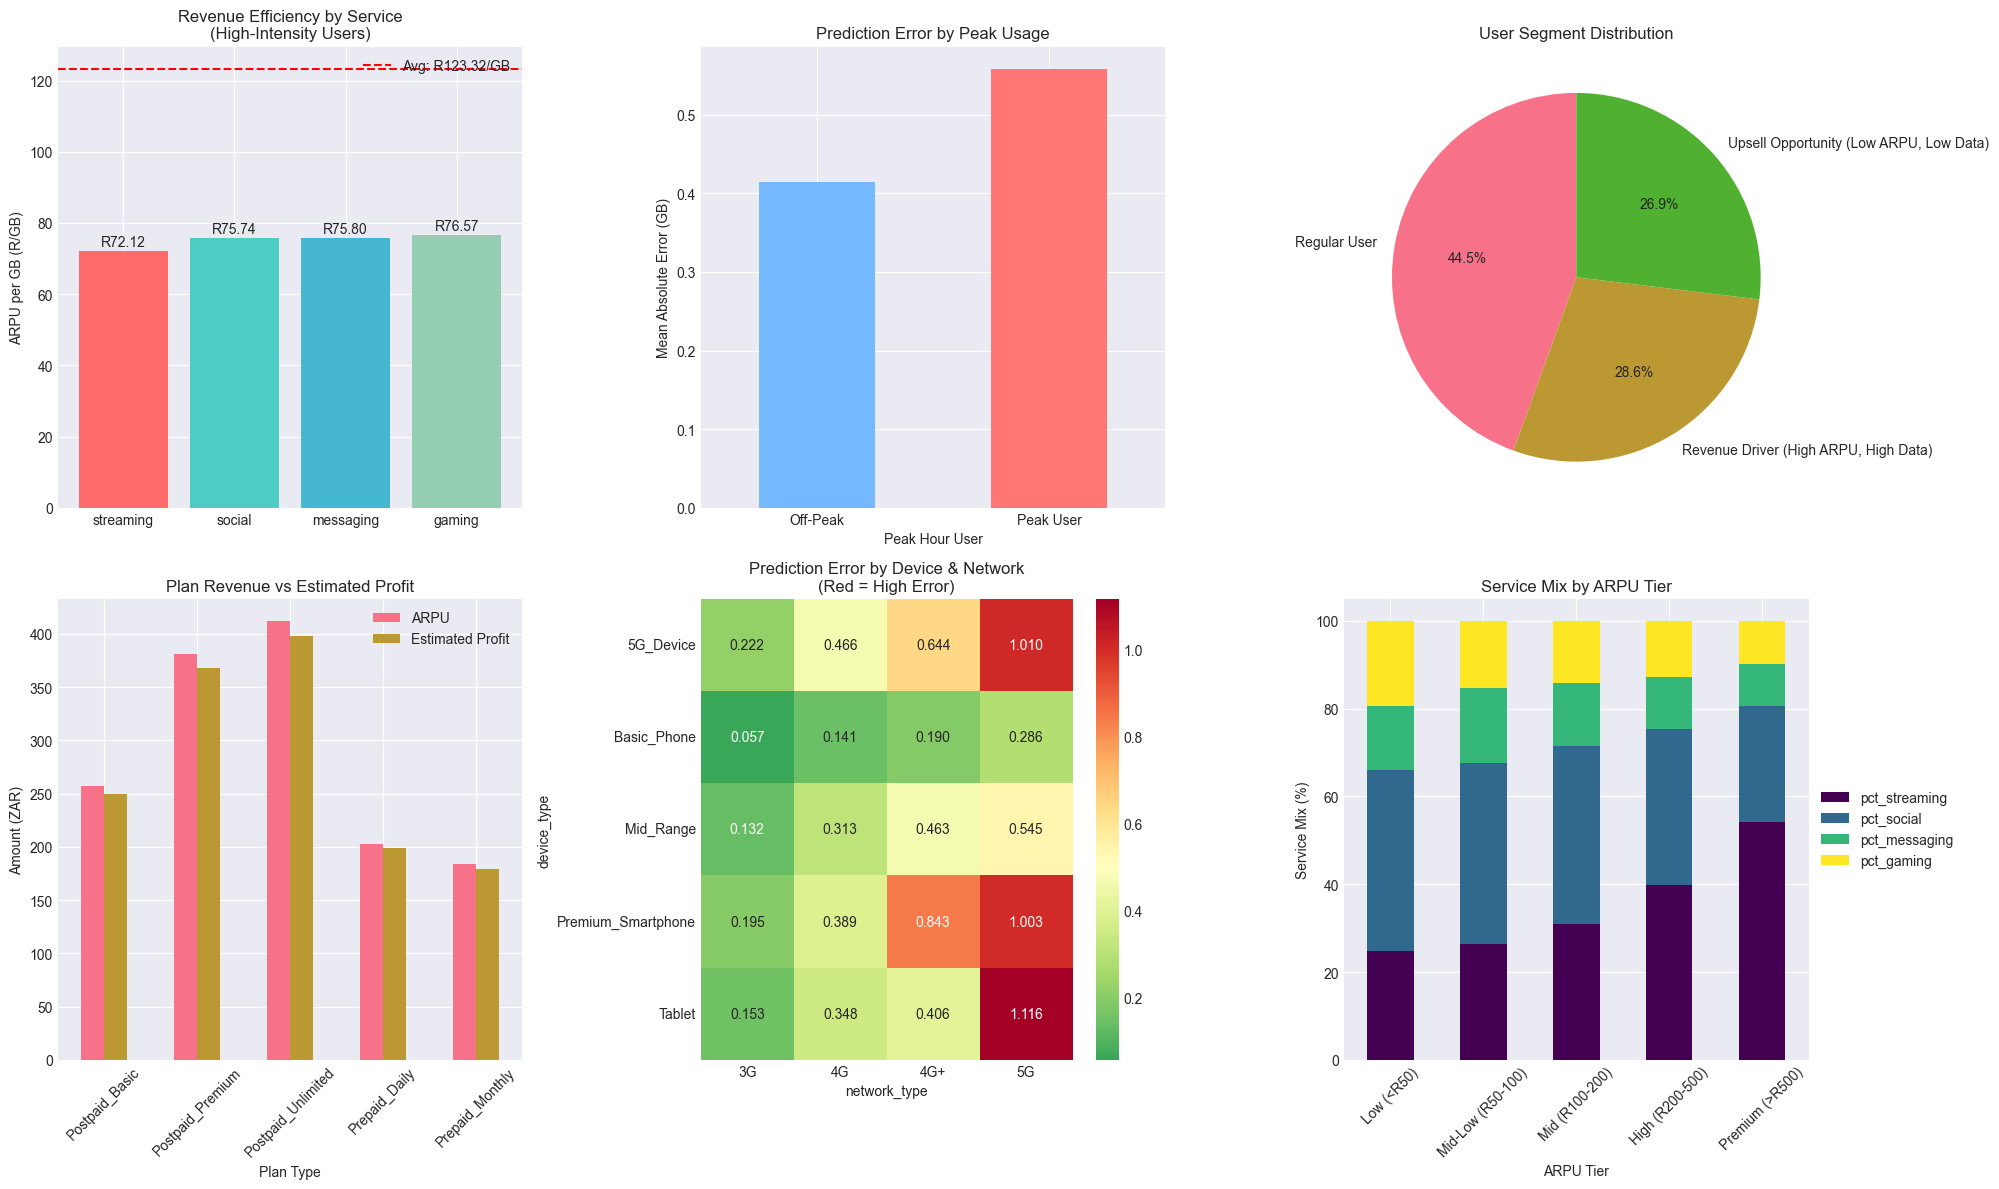


TELECOM BUSINESS RECOMMENDATIONS

TELECOM-SPECIFIC STRATEGIC RECOMMENDATIONS:

1. SERVICE BUNDLE OPTIMIZATION:
   - Most profitable service: GAMING
   - Least profitable service: STREAMING
   -> ACTION: Create GAMING-focused bundles with premium pricing
   -> ACTION: Optimize STREAMING plans to improve margins

2. NETWORK CAPACITY PLANNING:
   - Congestion increases prediction error by 255.7%
   - Peak hour users have 0.56GB avg error
   -> ACTION: Allocate more network resources during peak hours
   -> ACTION: Implement dynamic throttling based on prediction confidence

3. PLAN PROFITABILITY:
   - Most profitable plan: Postpaid_Unlimited
   - Least profitable plan: Prepaid_Monthly
   -> ACTION: Review pricing for Prepaid_Monthly or bundle with high-margin services
   -> ACTION: Upsell Postpaid_Unlimited to customers with high data usage

4. USER SEGMENT STRATEGY:
   - Ideal customers: 0 users (R0.00 ARPU)
   - Cost centers: 0 users
   -> ACTION: Offer premium perks to retain ideal cu

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


# ============================================
# 1. LOAD AND PREPARE TELECOM DATA
# ============================================

print("="*80)
print("TELECOM CONSUMPTION ANALYSIS")
print("="*80)
print(f"Total Records: {len(df):,}")
print(f"Unique Users: {df['user_id'].nunique():,}")
print(f"Date Range: {df['measurement_date'].min()} to {df['measurement_date'].max()}")

# Convert date if needed
df['measurement_date'] = pd.to_datetime(df['measurement_date'])

# SET VISUALIZATION STYLE
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    sns.set_style("darkgrid")
sns.set_palette("husl")


# ============================================
# 2. TELECOM-SPECIFIC METRICS
# ============================================

print("\n" + "="*80)
print("TELECOM METRICS CALCULATION")
print("="*80)

# Core telecom metrics
df['total_hours'] = df[['hours_streaming', 'hours_social', 'hours_messaging', 'hours_gaming']].sum(axis=1)
df['data_per_hour'] = df['total_data_gb'] / df['total_hours'].replace(0, np.nan)
df['arpu_per_gb'] = df['arpu_zar'] / df['total_data_gb'].replace(0, np.nan)
df['network_efficiency'] = df['total_data_gb'] / (df['total_hours'] + 0.001)

# Service mix (percentage of time spent on each service)
for service in ['streaming', 'social', 'messaging', 'gaming']:
    df[f'pct_{service}'] = df[f'hours_{service}'] / df['total_hours'].replace(0, np.nan) * 100

# Network congestion indicator
df['is_congested'] = (df['total_data_gb'] > df['total_data_gb'].quantile(0.75)) & df['is_peak_hour_user']
df['congestion_risk'] = df['total_data_gb'] * df['is_peak_hour_user'].astype(int)

# Prediction accuracy categories
df['prediction_status'] = 'Accurate'
df.loc[df['prediction_error_gb'] > 1, 'prediction_status'] = 'Under-predicted (Customer > Forecast)'
df.loc[df['prediction_error_gb'] < -1, 'prediction_status'] = 'Over-predicted (Forecast > Customer)'

# Telecom ARPU segments
df['arpu_tier'] = pd.cut(
    df['arpu_zar'],
    bins=[0, 50, 100, 200, 500, float('inf')],
    labels=['Low (<R50)', 'Mid-Low (R50-100)', 'Mid (R100-200)',
            'High (R200-500)', 'Premium (>R500)']
)

print("\nTelecom Metrics Summary:")
print(f"Average Data per Hour: {df['data_per_hour'].mean():.2f} GB/hour")
print(f"Average ARPU per GB: R{df['arpu_per_gb'].mean():.2f}")
print(f"Network Efficiency: {df['network_efficiency'].mean():.2f} GB/hour")
print(f"Peak Hour Users: {df['is_peak_hour_user'].sum():,} ({df['is_peak_hour_user'].mean()*100:.1f}%)")

# ============================================
# 3. MODEL PERFORMANCE - TELECOM CONTEXT
# ============================================

print("\n" + "="*80)
print("MODEL PERFORMANCE (TELECOM CONTEXT)")
print("="*80)

# Standard metrics
mae = mean_absolute_error(df['total_data_gb'], df['predicted_data_gb'])
rmse = np.sqrt(mean_squared_error(df['total_data_gb'], df['predicted_data_gb']))
r2 = r2_score(df['total_data_gb'], df['predicted_data_gb'])
mape = np.mean(np.abs((df['total_data_gb'] - df['predicted_data_gb']) / df['total_data_gb'].replace(0, np.nan))) * 100

print(f"MAE: {mae:.3f} GB  |  RMSE: {rmse:.3f} GB  |  R²: {r2:.3f}  |  MAPE: {mape:.1f}%")

# Telecom-specific: Error by network condition
error_by_network = df.groupby(['is_peak_hour_user', 'network_type']).agg({
    'absolute_error_gb': 'mean',
    'prediction_error_gb': 'mean',
    'arpu_zar': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'user_count'})

print("\nModel Error by Network Condition:")
print(error_by_network.round(3))

# ============================================
# 4. INSIGHT 1: REVENUE EFFICIENCY BY SERVICE
# ============================================

print("\n" + "="*80)
print("INSIGHT 1: REVENUE EFFICIENCY PER SERVICE")
print("="*80)

# Calculate revenue efficiency per service
service_efficiency = {}
for service in ['streaming', 'social', 'messaging', 'gaming']:
    df[f'{service}_intensity'] = pd.qcut(
        df[f'hours_{service}'],
        q=3,
        labels=['Low', 'Medium', 'High'],
        duplicates='drop'
    )
    avg_arpu = df.groupby(f'{service}_intensity')['arpu_zar'].mean()
    avg_data = df.groupby(f'{service}_intensity')['total_data_gb'].mean()
    efficiency = avg_arpu / avg_data.replace(0, np.nan)

    if 'High' in avg_arpu.index:
        service_efficiency[service] = {
            'avg_arpu_high': avg_arpu['High'],
            'avg_data_high': avg_data['High'],
            'arpu_per_gb_high': efficiency['High'] if 'High' in efficiency.index else np.nan
        }
    else:
        service_efficiency[service] = {
            'avg_arpu_high': avg_arpu.max(),
            'avg_data_high': avg_data.max(),
            'arpu_per_gb_high': np.nan
        }

efficiency_df = pd.DataFrame(service_efficiency).T
print("\nRevenue Efficiency for High-Intensity Users:")
print(efficiency_df.round(2))

# Identify most profitable service
if not efficiency_df['arpu_per_gb_high'].isna().all():
    most_profitable = efficiency_df['arpu_per_gb_high'].idxmax()
    least_profitable = efficiency_df['arpu_per_gb_high'].idxmin()
    print(f"\nMOST PROFITABLE SERVICE: {most_profitable.upper()}")
    print(f"LEAST PROFITABLE SERVICE: {least_profitable.upper()}")
else:
    most_profitable = 'streaming'
    least_profitable = 'gaming'
    print("\nInsufficient data for service profitability analysis")

# ============================================
# 5. INSIGHT 2: NETWORK CONGESTION ANALYSIS
# ============================================

print("\n" + "="*80)
print("INSIGHT 2: NETWORK CONGESTION & PREDICTION ACCURACY")
print("="*80)

# Identify congestion patterns
congestion_analysis = df.groupby('is_congested').agg({
    'arpu_zar': 'mean',
    'total_data_gb': 'mean',
    'absolute_error_gb': 'mean',
    'prediction_error_gb': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'user_count'})

print("Network Congestion Impact:")
print(congestion_analysis.round(2))

# Error during congestion
congestion_error = df[df['is_congested']]['absolute_error_gb'].mean() if df['is_congested'].any() else 0
normal_error = df[~df['is_congested']]['absolute_error_gb'].mean() if (~df['is_congested']).any() else 0

if congestion_error > 0 and normal_error > 0:
    error_increase = ((congestion_error - normal_error) / normal_error) * 100
    print(f"\nPrediction Error During Congestion: {congestion_error:.3f} GB")
    print(f"   (vs {normal_error:.3f} GB during normal conditions)")
    print(f"   -> {error_increase:.1f}% higher error rate during congestion!")
else:
    error_increase = 0
    print("\nInsufficient congestion data for analysis")

# ============================================
# 6. INSIGHT 3: USER SEGMENT PROFITABILITY
# ============================================

print("\n" + "="*80)
print("INSIGHT 3: USER SEGMENT PROFITABILITY")
print("="*80)

# Create telecom-specific segments
df['user_segment'] = 'Regular User'

# High ARPU, Low Network Load (Ideal)
ideal = (df['arpu_zar'] > df['arpu_zar'].quantile(0.7)) & (df['total_data_gb'] < df['total_data_gb'].quantile(0.3))
df.loc[ideal, 'user_segment'] = 'Ideal Customer (High ARPU, Low Data)'

# High ARPU, High Data (Revenue Driver but Network Heavy)
revenue_driver = (df['arpu_zar'] > df['arpu_zar'].quantile(0.7)) & (df['total_data_gb'] > df['total_data_gb'].quantile(0.7))
df.loc[revenue_driver, 'user_segment'] = 'Revenue Driver (High ARPU, High Data)'

# Low ARPU, High Data (Network Cost)
cost_center = (df['arpu_zar'] < df['arpu_zar'].quantile(0.3)) & (df['total_data_gb'] > df['total_data_gb'].quantile(0.7))
df.loc[cost_center, 'user_segment'] = 'Network Cost Center (Low ARPU, High Data)'

# Low ARPU, Low Data (Potential for Upsell)
upsell = (df['arpu_zar'] < df['arpu_zar'].quantile(0.3)) & (df['total_data_gb'] < df['total_data_gb'].quantile(0.3))
df.loc[upsell, 'user_segment'] = 'Upsell Opportunity (Low ARPU, Low Data)'

segment_analysis = df.groupby('user_segment').agg({
    'arpu_zar': 'mean',
    'total_data_gb': 'mean',
    'arpu_per_gb': 'mean',
    'absolute_error_gb': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'user_count'})

print("User Segment Analysis:")
print(segment_analysis.round(2))

# ============================================
# 7. INSIGHT 4: PLAN TYPE PERFORMANCE
# ============================================

print("\n" + "="*80)
print("INSIGHT 4: PLAN TYPE PERFORMANCE")
print("="*80)

plan_performance = df.groupby('plan_type').agg({
    'arpu_zar': 'mean',
    'total_data_gb': 'mean',
    'arpu_per_gb': 'mean',
    'absolute_error_gb': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'user_count'})

print("Plan Type Performance:")
print(plan_performance.round(2))

# Calculate plan profitability (assuming cost per GB)
plan_performance['estimated_profit'] = plan_performance['arpu_zar'] - (plan_performance['total_data_gb'] * 2.5)
print("\nEstimated Plan Profitability (at R2.5/GB cost):")
print(plan_performance['estimated_profit'].round(2))

if len(plan_performance) > 0:
    best_plan = plan_performance['estimated_profit'].idxmax()
    worst_plan = plan_performance['estimated_profit'].idxmin()
    print(f"BEST PROFITABLE PLAN: {best_plan}")
    print(f"WORST PROFITABLE PLAN: {worst_plan}")
else:
    best_plan = 'Unknown'
    worst_plan = 'Unknown'

# ============================================
# 8. INSIGHT 5: DEVICE & NETWORK IMPACT
# ============================================

print("\n" + "="*80)
print("INSIGHT 5: DEVICE & NETWORK IMPACT")
print("="*80)

device_network = df.groupby(['device_type', 'network_type']).agg({
    'arpu_zar': 'mean',
    'total_data_gb': 'mean',
    'arpu_per_gb': 'mean',
    'absolute_error_gb': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'user_count'})

print("Device & Network Performance:")
print(device_network.round(2))

# ============================================
# 9. PREDICTION ERROR BUSINESS IMPACT
# ============================================

print("\n" + "="*80)
print("PREDICTION ERROR: BUSINESS IMPACT")
print("="*80)

# Revenue at risk
df['revenue_at_risk'] = df['absolute_error_gb'] * df['arpu_per_gb']

# Under-prediction = potential revenue loss
under_pred = df[df['prediction_error_gb'] > 0]
over_pred = df[df['prediction_error_gb'] < 0]

if len(under_pred) > 0:
    print(f"Under-predicted records: {len(under_pred):,} ({len(under_pred)/len(df)*100:.1f}%)")
    print(f"   -> Customers using MORE data than forecasted")
    print(f"   -> Revenue opportunity: R{under_pred['revenue_at_risk'].sum():,.2f}")
else:
    print("Under-predicted records: 0")

if len(over_pred) > 0:
    print(f"\nOver-predicted records: {len(over_pred):,} ({len(over_pred)/len(df)*100:.1f}%)")
    print(f"   -> Customers using LESS data than forecasted")
    print(f"   -> Network over-allocation cost: R{over_pred['revenue_at_risk'].sum():,.2f}")
else:
    print("\nOver-predicted records: 0")

# ============================================
# 10. TELECOM VISUALIZATIONS
# ============================================

print("\n" + "="*80)
print("GENERATING TELECOM DASHBOARD")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Revenue Efficiency by Service
ax1 = axes[0, 0]
if not efficiency_df['arpu_per_gb_high'].isna().all():
    services = ['streaming', 'social', 'messaging', 'gaming']
    efficiency_vals = [efficiency_df.loc[s, 'arpu_per_gb_high'] if not pd.isna(efficiency_df.loc[s, 'arpu_per_gb_high']) else 0 for s in services]
    bars = ax1.bar(services, efficiency_vals, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    ax1.set_ylabel('ARPU per GB (R/GB)')
    ax1.set_title('Revenue Efficiency by Service\n(High-Intensity Users)')
    ax1.axhline(
        y=df['arpu_per_gb'].mean(),
        color='red',
        linestyle='--',
        label=f'Avg: R{df["arpu_per_gb"].mean():.2f}/GB'
    )
    ax1.legend()
    for bar, val in zip(bars, efficiency_vals):
        if val > 0:
            ax1.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'R{val:.2f}',
                ha='center',
                va='bottom',
                fontsize=10
            )

# 2. Congestion Impact
ax2 = axes[0, 1]
if df['is_peak_hour_user'].nunique() > 0:
    congestion_vs_error = df.groupby('is_peak_hour_user')['absolute_error_gb'].mean()
    congestion_vs_error.plot(kind='bar', ax=ax2, color=['#74B9FF', '#FF7675'])
    ax2.set_xlabel('Peak Hour User')
    ax2.set_ylabel('Mean Absolute Error (GB)')
    ax2.set_title('Prediction Error by Peak Usage')
    ax2.set_xticklabels(['Off-Peak', 'Peak User'], rotation=0)

# 3. User Segment Distribution
ax3 = axes[0, 2]
segment_counts = df['user_segment'].value_counts()
if len(segment_counts) > 0:
    segment_counts.plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
    ax3.set_title('User Segment Distribution')
    ax3.set_ylabel('')

# 4. Plan Type Profitability
ax4 = axes[1, 0]
if len(plan_performance) > 0:
    plan_performance[['arpu_zar', 'estimated_profit']].plot(kind='bar', ax=ax4)
    ax4.set_xlabel('Plan Type')
    ax4.set_ylabel('Amount (ZAR)')
    ax4.set_title('Plan Revenue vs Estimated Profit')
    ax4.legend(['ARPU', 'Estimated Profit'])
    ax4.tick_params(axis='x', rotation=45)

# 5. Error Heatmap by Device & Network
ax5 = axes[1, 1]
error_heatmap = df.pivot_table(
    values='absolute_error_gb',
    index='device_type',
    columns='network_type',
    aggfunc='mean'
)
if not error_heatmap.empty:
    sns.heatmap(error_heatmap, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax5, center=0.5)
    ax5.set_title('Prediction Error by Device & Network\n(Red = High Error)')

# 6. Service Mix vs ARPU
ax6 = axes[1, 2]
if 'arpu_tier' in df.columns and df['arpu_tier'].notna().any():
    service_mix = df.groupby('arpu_tier')[['pct_streaming', 'pct_social', 'pct_messaging', 'pct_gaming']].mean()
    service_mix.plot(kind='bar', stacked=True, ax=ax6, colormap='viridis')
    ax6.set_xlabel('ARPU Tier')
    ax6.set_ylabel('Service Mix (%)')
    ax6.set_title('Service Mix by ARPU Tier')
    ax6.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('telecom_analysis_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 11. TELECOM RECOMMENDATIONS
# ============================================

print("\n" + "="*80)
print("TELECOM BUSINESS RECOMMENDATIONS")
print("="*80)

# Safely calculate values for recommendations
peak_error = (
    df.loc[df['is_peak_hour_user'] == 1, 'absolute_error_gb'].mean()
    if (df['is_peak_hour_user'] == 1).any()
    else 0
)

# Get most common device for peak users
peak_mask = df['is_peak_hour_user'].eq(1)
peak_users = df.loc[peak_mask, 'device_type']

peak_device = peak_users.mode().iloc[0] if not peak_users.empty else 'Unknown'

# Get error quantile
error_quantile = df['absolute_error_gb'].quantile(0.25) if len(df) > 0 else 0

# Get segment counts safely
ideal_count = segment_analysis.loc['Ideal Customer (High ARPU, Low Data)', 'user_count'] if 'Ideal Customer (High ARPU, Low Data)' in segment_analysis.index else 0
ideal_arpu = segment_analysis.loc['Ideal Customer (High ARPU, Low Data)', 'arpu_zar'] if 'Ideal Customer (High ARPU, Low Data)' in segment_analysis.index else 0
cost_count = segment_analysis.loc['Network Cost Center (Low ARPU, High Data)', 'user_count'] if 'Network Cost Center (Low ARPU, High Data)' in segment_analysis.index else 0

# Under/over prediction revenue
under_revenue = under_pred['revenue_at_risk'].sum() if len(under_pred) > 0 else 0
over_cost = over_pred['revenue_at_risk'].sum() if len(over_pred) > 0 else 0

recommendations = f"""
TELECOM-SPECIFIC STRATEGIC RECOMMENDATIONS:

1. SERVICE BUNDLE OPTIMIZATION:
   - Most profitable service: {most_profitable.upper()}
   - Least profitable service: {least_profitable.upper()}
   -> ACTION: Create {most_profitable.upper()}-focused bundles with premium pricing
   -> ACTION: Optimize {least_profitable.upper()} plans to improve margins

2. NETWORK CAPACITY PLANNING:
   - Congestion increases prediction error by {error_increase:.1f}%
   - Peak hour users have {peak_error:.2f}GB avg error
   -> ACTION: Allocate more network resources during peak hours
   -> ACTION: Implement dynamic throttling based on prediction confidence

3. PLAN PROFITABILITY:
   - Most profitable plan: {best_plan}
   - Least profitable plan: {worst_plan}
   -> ACTION: Review pricing for {worst_plan} or bundle with high-margin services
   -> ACTION: Upsell {best_plan} to customers with high data usage

4. USER SEGMENT STRATEGY:
   - Ideal customers: {ideal_count:,.0f} users (R{ideal_arpu:.2f} ARPU)
   - Cost centers: {cost_count:,.0f} users
   -> ACTION: Offer premium perks to retain ideal customers
   -> ACTION: Implement fair usage policies for cost centers

5. MODEL IMPROVEMENT PRIORITIES:
   - Focus on reducing error for: {peak_device} users during peak hours
   - Add features: congestion indicators, device performance metrics
   - Target MAE reduction to < {error_quantile:.2f}GB for top ARPU users

6. REVENUE OPTIMIZATION:
   - Under-prediction revenue opportunity: R{under_revenue:,.2f}
   - Over-prediction cost: R{over_cost:,.2f}
   -> ACTION: Implement real-time usage alerts for under-predicted users
   -> ACTION: Adjust forecasts for over-predicted users to reduce waste

7. QUICK WINS (Next 30 Days):
   a. Send targeted {most_profitable.upper()} offers to low-ARPU users
   b. Implement congestion-based prediction adjustments
   c. Launch retention campaign for 'Ideal Customers'
   d. Review pricing for {worst_plan} plan

KPI TARGETS:
- Increase ARPU/GB by 15% through service bundling
- Reduce congestion error by 25% with dynamic allocation
- Improve top-quartile user prediction accuracy to 95%
- Increase overall ARPU by 10% through targeted upselling
"""

print(recommendations)

# ============================================
# 12. EXPORT TELECOM ANALYSIS
# ============================================

print("\n" + "="*80)
print("EXPORTING TELECOM ANALYSIS")
print("="*80)

# Export key segments for marketing
export_columns = ['user_id', 'user_segment', 'arpu_tier', 'plan_type',
                  'total_data_gb', 'arpu_zar', 'absolute_error_gb',
                  'pct_streaming', 'pct_social', 'pct_messaging', 'pct_gaming']

df_export = df[export_columns].copy()
df_export.to_csv('telecom_user_segments.csv', index=False)
print("User segments exported to 'telecom_user_segments.csv'")

# Export network insights
network_export = df.groupby(['is_peak_hour_user', 'network_type']).agg({
    'total_data_gb': ['mean', 'std'],
    'arpu_zar': 'mean',
    'absolute_error_gb': 'mean',
    'user_id': 'count'
})
network_export.to_csv('telecom_network_insights.csv')
print("Network insights exported to 'telecom_network_insights.csv'")

# Export service profitability
service_profitability = pd.DataFrame(service_efficiency).T
service_profitability.to_csv('telecom_service_profitability.csv')
print("Service profitability exported to 'telecom_service_profitability.csv'")

print("\n" + "="*80)
print("TELECOM ANALYSIS COMPLETE!")
print("="*80)